In [ ]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
from IPython.display import display

from data_utils import (
    RANDOM_STATE,
    IMAGE_SIZE,
    BATCH_SIZE,
    NUM_WORKERS,
    TARGET_COLUMNS,
    TARGET_NAMES,
    seed_everything,
    prepare_splits,
    build_transforms,
    PhotoQualityDataset,
    create_loaders,
)

In [4]:
seed_everything(RANDOM_STATE)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Пристрій:", device)

if device.type == "cuda":
    print("Відеокарта:", torch.cuda.get_device_name(0))
else:
    print("GPU не підключений.")

Пристрій: cpu
GPU не підключений.


In [5]:
DEBUG_MODE = True
NUM_EPOCHS = 7 if DEBUG_MODE else 20

LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 0.00001

MODEL_NAME = "ResNet18"
MODEL_PREFIX = "resnet_feature_extraction"
ARCHITECTURE = "resnet18"
TRAINING_STRATEGY = "Feature Extraction"

In [6]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_manifest.csv"
IMAGES_DIRECTORY = PROJECT_ROOT / "data" / "raw" / "SPAQ_small"

MODELS_DIRECTORY = PROJECT_ROOT / "artifacts" / "models"
RESULTS_DIRECTORY = PROJECT_ROOT / "artifacts" / "results"

MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIRECTORY / f"{MODEL_PREFIX}_best.pt"
HISTORY_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_history.csv"
METRICS_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_metrics.csv"
TARGET_METRICS_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_metrics_by_target.csv"
PREDICTIONS_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_predictions.csv"

LOSS_PLOT_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_loss.png"
SCATTER_PLOT_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_scatter.png"

print("Manifest:", MANIFEST_PATH)
print("Фотографії:", IMAGES_DIRECTORY)
print("Модель:", MODEL_PATH)
print("Результати:", RESULTS_DIRECTORY)

Manifest: c:\Users\Admin\Desktop\PhotoAnalyser\data\processed\dataset_manifest.csv
Фотографії: c:\Users\Admin\Desktop\PhotoAnalyser\data\raw\SPAQ_small
Модель: c:\Users\Admin\Desktop\PhotoAnalyser\artifacts\models\resnet_feature_extraction_best.pt
Результати: c:\Users\Admin\Desktop\PhotoAnalyser\artifacts\results


Підготовка даних

In [7]:
manifest = pd.read_csv(MANIFEST_PATH)

print("Розмір manifest:", manifest.shape)
print("Колонки:")

print(manifest.columns.tolist())

display(manifest.head())

Розмір manifest: (11125, 12)
Колонки:
['image_name', 'overall_quality', 'brightness_quality', 'colorfulness_quality', 'contrast_quality', 'noise_quality', 'sharpness_quality', 'width', 'height', 'color_mode', 'quality_bin', 'split']


,image_name,overall_quality,brightness_quality,colorfulness_quality,contrast_quality,noise_quality,sharpness_quality,width,height,color_mode,quality_bin,split
0,02051.jpg,20.63,30.88,39.88,28.63,13.71,14.88,512,384,RGB,0,test
1,03819.jpg,70.71,67.43,68.57,74.71,74.00,66.86,384,512,RGB,7,train
2,02746.jpg,71.00,67.27,70.72,61.87,63.42,69.22,384,512,RGB,7,validation
3,06586.jpg,72.83,71.50,75.00,70.67,71.33,74.00,384,512,RGB,8,test
4,01016.jpg,38.14,64.29,63.43,52.25,28.75,25.63,512,383,RGB,3,train


In [8]:
train_dataframe, validation_dataframe, test_dataframe = prepare_splits(
    manifest=manifest,
    debug_mode=DEBUG_MODE,
    random_state=RANDOM_STATE,
)

print("Train:", len(train_dataframe))
print("Validation:", len(validation_dataframe))
print("Test:", len(test_dataframe))

Train: 3000
Validation: 600
Test: 600


In [9]:
train_transform, evaluation_transform = build_transforms(
    image_size=IMAGE_SIZE,
)

In [10]:
train_dataset = PhotoQualityDataset(
    dataframe=train_dataframe,
    images_directory=IMAGES_DIRECTORY,
    target_columns=TARGET_COLUMNS,
    transform=train_transform,
)

validation_dataset = PhotoQualityDataset(
    dataframe=validation_dataframe,
    images_directory=IMAGES_DIRECTORY,
    target_columns=TARGET_COLUMNS,
    transform=evaluation_transform,
)

test_dataset = PhotoQualityDataset(
    dataframe=test_dataframe,
    images_directory=IMAGES_DIRECTORY,
    target_columns=TARGET_COLUMNS,
    transform=evaluation_transform,
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(validation_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 3000
Validation dataset: 600
Test dataset: 600


In [11]:
sample_image, sample_targets, sample_name = validation_dataset[0]

print("Фото:", sample_name)
print("Форма зображення:", sample_image.shape)
print("Оцінки:", sample_targets * 100)

Фото: 06925.jpg
Форма зображення: torch.Size([3, 224, 224])
Оцінки: tensor([53.0000, 58.8000, 50.4000, 57.8000, 44.2000, 55.6000])


In [12]:
train_loader, validation_loader, test_loader = create_loaders(
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    test_dataset=test_dataset,
    device=device,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    random_state=RANDOM_STATE,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Train batches: 188
Validation batches: 38
Test batches: 38


Архітектура моделі ResNet18 з замороженими вагами (навчається лише останній шар)

In [13]:
def create_resnet18_feature_extractor(number_of_outputs):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    for parameter in model.parameters():
        parameter.requires_grad = False

    number_of_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(number_of_features, number_of_outputs),
        nn.Sigmoid(),
    )

    return model

In [14]:
model = create_resnet18_feature_extractor(
    number_of_outputs=len(TARGET_COLUMNS)
)

model = model.to(device)

print(model.fc)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=6, bias=True)
  (2): Sigmoid()
)


In [15]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Усього параметрів:", total_parameters)
print("Навчуваних параметрів:", trainable_parameters)

Усього параметрів: 11179590
Навчуваних параметрів: 3078


In [16]:
print("Навчувані шари:")

for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name, parameter.shape)

Навчувані шари:
fc.1.weight torch.Size([6, 512])
fc.1.bias torch.Size([6])


Loss, optimizer, scheduler

In [17]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=0.000001,
)

Функції для навчання

In [18]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.eval()
    model.fc.train()

    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Train", leave=False)

    for images, targets, _ in progress_bar:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        progress_bar.set_postfix(loss=f"{loss.item():.5f}")

    return total_loss / len(dataloader.dataset)

In [19]:
def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, targets, _ in tqdm(
            dataloader,
            desc="Validation",
            leave=False,
        ):
            images = images.to(device)
            targets = targets.to(device)

            predictions = model(images)
            loss = criterion(predictions, targets)

            total_loss += loss.item() * images.size(0)

    return total_loss / len(dataloader.dataset)

In [20]:
history = []

best_validation_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

Навчання моделі

In [ ]:
training_start_time = time.perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nЕпоха {epoch}/{NUM_EPOCHS}")

    current_learning_rate = optimizer.param_groups[0]["lr"]

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    validation_loss = evaluate_loss(
        model=model,
        dataloader=validation_loader,
        criterion=criterion,
        device=device,
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_loss,
        "backbone_learning_rate": None,
        "head_learning_rate": current_learning_rate,
    })

    print(f"Train loss: {train_loss:.6f}")
    print(f"Validation loss: {validation_loss:.6f}")
    print(f"Learning rate: {current_learning_rate:.7f}")

    scheduler.step(validation_loss)

    if validation_loss < best_validation_loss - MIN_DELTA:
        best_validation_loss = validation_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "architecture": ARCHITECTURE,
                "training_strategy": TRAINING_STRATEGY,
                "target_columns": TARGET_COLUMNS,
                "image_size": IMAGE_SIZE,
                "random_state": RANDOM_STATE,
                "best_epoch": best_epoch,
                "best_validation_loss": best_validation_loss,
            },
            MODEL_PATH,
        )

        print("Збережено нову найкращу модель")
    else:
        epochs_without_improvement += 1
        print("Епох без покращення:", epochs_without_improvement)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping")
        break

training_time_seconds = time.perf_counter() - training_start_time

history_dataframe = pd.DataFrame(history)


Епоха 1/7


Train:   0%|          | 0/188 [00:00<?, ?it/s]

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train loss: 0.034007
Validation loss: 0.022069
Learning rate: 0.0010000
Збережено нову найкращу модель

Епоха 2/7


Train:   0%|          | 0/188 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train loss: 0.020203
Validation loss: 0.019466
Learning rate: 0.0010000
Епох без покращення: 2

Епоха 7/7


Train:   0%|          | 0/188 [00:00<?, ?it/s]

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train loss: 0.021812
Validation loss: 0.022092
Learning rate: 0.0010000
Епох без покращення: 3


In [22]:
print("Найкраща епоха:", best_epoch)
print("Найкращий validation loss:", round(best_validation_loss, 6))
print("Час навчання, хв:", round(training_time_seconds / 60, 2))
print("Модель збережена:", MODEL_PATH)

Найкраща епоха: 4
Найкращий validation loss: 0.017718
Час навчання, хв: 15.16
Модель збережена: c:\Users\Admin\Desktop\PhotoAnalyser\artifacts\models\resnet_feature_extraction_best.pt


In [23]:
history_dataframe.to_csv(
    HISTORY_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(history_dataframe)

,epoch,train_loss,validation_loss,backbone_learning_rate,head_learning_rate
0,1,0.034007,0.022069,None,0.001
1,2,0.023582,0.018709,None,0.001
2,3,0.021918,0.018422,None,0.001
3,4,0.020974,0.017718,None,0.001
4,5,0.020540,0.026992,None,0.001
5,6,0.020203,0.019466,None,0.001
6,7,0.021812,0.022092,None,0.001


Оцінка на test

In [24]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Завантажено модель з епохи:", checkpoint["best_epoch"])

Завантажено модель з епохи: 4


In [ ]:
def predict_dataset(model, dataloader, device):
    model.eval()

    all_predictions = []
    all_targets = []
    all_image_names = []

    with torch.no_grad():
        for images, targets, image_names in tqdm(
            dataloader,
            desc="Test predictions",
        ):
            images = images.to(device)
            predictions = model(images)

            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.numpy())
            all_image_names.extend(image_names)

    predictions = np.concatenate(all_predictions, axis=0) * 100.0
    targets = np.concatenate(all_targets, axis=0) * 100.0

    return predictions, targets, all_image_names

In [26]:
test_predictions, test_targets, test_image_names = predict_dataset(
    model=model,
    dataloader=test_loader,
    device=device,
)

print("Прогнози:", test_predictions.shape)
print("Правильні оцінки:", test_targets.shape)

Test predictions:   0%|          | 0/38 [00:00<?, ?it/s]

Прогнози: (600, 6)
Правильні оцінки: (600, 6)


Метрики якості
MAE, RMSE, PLCC, SRCC по кожному параметру

In [27]:
mae_values = np.mean(
    np.abs(test_predictions - test_targets),
    axis=0,
)

rmse_values = np.sqrt(
    np.mean(
        (test_predictions - test_targets) ** 2,
        axis=0,
    )
)

In [28]:
metrics_rows = []

for index, target_column in enumerate(TARGET_COLUMNS):
    true_values = test_targets[:, index]
    predicted_values = test_predictions[:, index]

    metrics_rows.append({
        "target_column": target_column,
        "parameter": TARGET_NAMES[index],
        "mae": mae_values[index],
        "rmse": rmse_values[index],
        "plcc": pearsonr(true_values, predicted_values)[0],
        "srcc": spearmanr(true_values, predicted_values)[0],
    })

metrics_dataframe = pd.DataFrame(metrics_rows)

metrics_dataframe.to_csv(
    TARGET_METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(metrics_dataframe.round(4))

,target_column,parameter,mae,rmse,plcc,srcc
0,overall_quality,Загальна якість,10.6240,13.3424,0.7835,0.7803
1,brightness_quality,Яскравість,10.2501,12.7230,0.6647,0.6355
2,colorfulness_quality,Кольоровість,9.2142,11.4021,0.6758,0.6521
3,contrast_quality,Контраст,9.5677,11.8448,0.6911,0.6758
4,noise_quality,Якість щодо шуму,10.7720,13.4050,0.6929,0.6985
5,sharpness_quality,Різкість,12.3546,15.3136,0.7920,0.7824


Аналіз прогнозів

In [29]:
predictions_dataframe = pd.DataFrame({
    "image_name": test_image_names,
})

for index, column in enumerate(TARGET_COLUMNS):
    predictions_dataframe[f"true_{column}"] = test_targets[:, index]
    predictions_dataframe[f"predicted_{column}"] = test_predictions[:, index]

predictions_dataframe["overall_error"] = np.abs(
    predictions_dataframe["true_overall_quality"]
    - predictions_dataframe["predicted_overall_quality"]
)

display(predictions_dataframe.head())

predictions_dataframe.to_csv(
    PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

,image_name,true_overall_quality,predicted_overall_quality,true_brightness_quality,predicted_brightness_quality,true_colorfulness_quality,predicted_colorfulness_quality,true_contrast_quality,predicted_contrast_quality,true_noise_quality,predicted_noise_quality,true_sharpness_quality,predicted_sharpness_quality,overall_error
0,03280.jpg,15.410000,29.064226,18.270000,39.748844,26.670000,42.708332,21.500000,39.833553,24.559999,38.969433,10.750000,25.788927,13.654226
1,04131.jpg,73.570000,51.708019,70.709999,57.947773,70.290001,62.665367,75.860001,59.627567,67.290001,57.924973,73.709999,52.939026,21.861980
2,06680.jpg,34.430000,46.240673,45.430000,59.399952,37.139999,62.929947,40.570000,60.067551,28.430000,51.301090,17.000000,41.245689,11.810673
3,08880.jpg,86.000000,55.325584,84.669998,55.066895,86.330002,59.651585,85.000000,56.922768,86.779999,60.688740,85.330002,63.558514,30.674416
4,09996.jpg,34.709999,47.193825,51.570000,54.155731,46.000000,60.866570,43.000000,56.195778,25.000000,50.673752,21.139999,45.015640,12.483826


In [30]:
display(
    predictions_dataframe[
        [
            "image_name",
            "true_overall_quality",
            "predicted_overall_quality",
            "overall_error",
        ]
    ].head(10)
)

,image_name,true_overall_quality,predicted_overall_quality,overall_error
0,03280.jpg,15.410000,29.064226,13.654226
1,04131.jpg,73.570000,51.708019,21.861980
2,06680.jpg,34.430000,46.240673,11.810673
3,08880.jpg,86.000000,55.325584,30.674416
4,09996.jpg,34.709999,47.193825,12.483826
5,00997.jpg,78.500000,63.328064,15.171936
6,07810.jpg,70.669998,65.728516,4.941483
7,05078.jpg,79.500000,69.792267,9.707733
8,10422.jpg,74.199997,68.390305,5.809692
9,00538.jpg,24.150000,18.975548,5.174452


In [31]:
overall_metrics = metrics_dataframe.iloc[0]

summary_dataframe = pd.DataFrame([{
    "model": MODEL_NAME,
    "training_strategy": TRAINING_STRATEGY,
    "mae": overall_metrics["mae"],
    "rmse": overall_metrics["rmse"],
    "plcc": overall_metrics["plcc"],
    "srcc": overall_metrics["srcc"],
    "best_epoch": checkpoint["best_epoch"],
    "validation_loss": checkpoint["best_validation_loss"],
    "training_time_seconds": training_time_seconds,
    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
}])

summary_dataframe.to_csv(
    METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(summary_dataframe.round(4))

,model,training_strategy,mae,rmse,plcc,srcc,best_epoch,validation_loss,training_time_seconds,total_parameters,trainable_parameters
0,ResNet18,Feature Extraction,10.624,13.3424,0.7835,0.7803,4,0.0177,909.8587,11179590,3078


Графік навчання train/validation loss по епохах

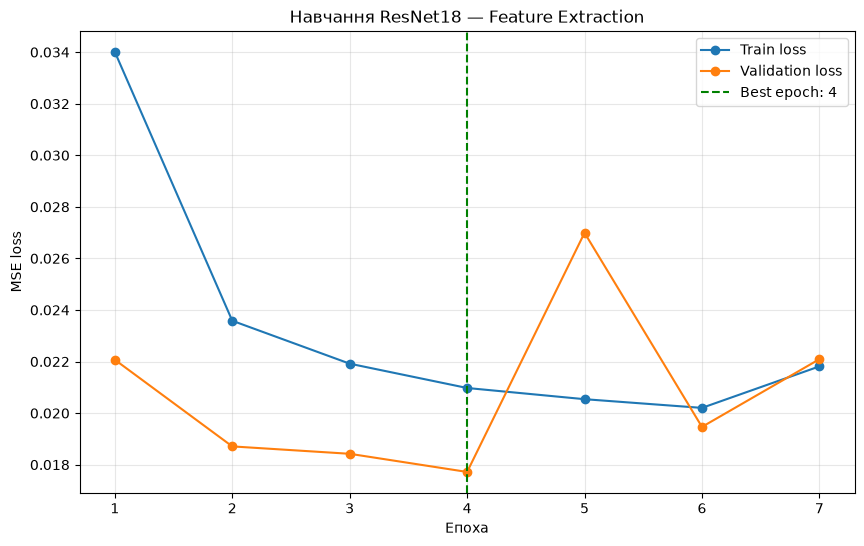

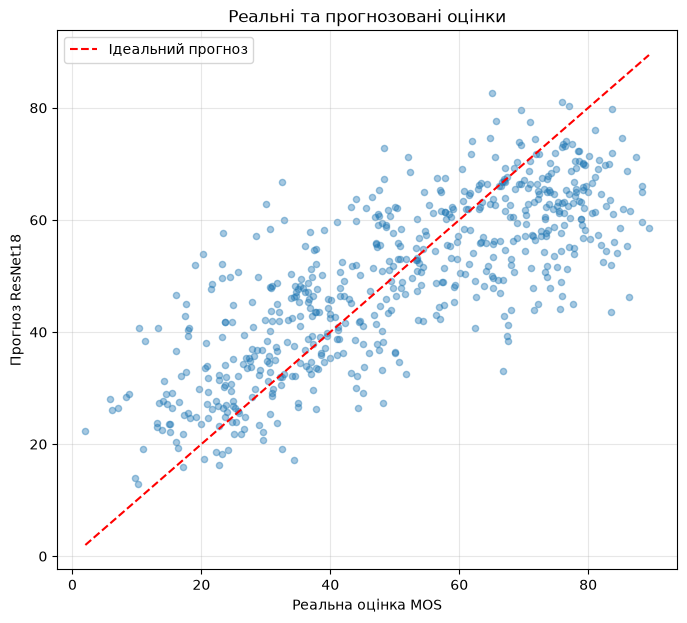

In [32]:
epochs = history_dataframe["epoch"]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_dataframe["train_loss"],
    marker="o",
    label="Train loss",
)

plt.plot(
    epochs,
    history_dataframe["validation_loss"],
    marker="o",
    label="Validation loss",
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

plt.xlabel("Епоха")
plt.ylabel("MSE loss")
plt.title("Навчання ResNet18 — Feature Extraction")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(LOSS_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()


true_overall = test_targets[:, 0]
predicted_overall = test_predictions[:, 0]

plt.figure(figsize=(8, 7))

plt.scatter(
    true_overall,
    predicted_overall,
    alpha=0.4,
    s=20,
)

minimum_score = min(
    true_overall.min(),
    predicted_overall.min(),
)

maximum_score = max(
    true_overall.max(),
    predicted_overall.max(),
)

plt.plot(
    [minimum_score, maximum_score],
    [minimum_score, maximum_score],
    color="red",
    linestyle="--",
    label="Ідеальний прогноз",
)

plt.xlabel("Реальна оцінка MOS")
plt.ylabel("Прогноз ResNet18")
plt.title("Реальні та прогнозовані оцінки")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(SCATTER_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

Найгірші прогнози

In [33]:
worst_predictions = (
    predictions_dataframe
    .sort_values(
        "overall_error",
        ascending=False,
    )
    .head(6)
)

display(
    worst_predictions[
        [
            "image_name",
            "true_overall_quality",
            "predicted_overall_quality",
            "overall_error",
        ]
    ]
)

,image_name,true_overall_quality,predicted_overall_quality,overall_error
355,09064.jpg,86.330002,46.172482,40.157520
215,08661.jpg,83.500000,43.560692,39.939308
599,10806.jpg,23.290001,57.626205,34.336205
241,08290.jpg,32.560001,66.850136,34.290134
455,00213.jpg,20.180000,53.932636,33.752636
281,07963.jpg,66.830002,33.078247,33.751755


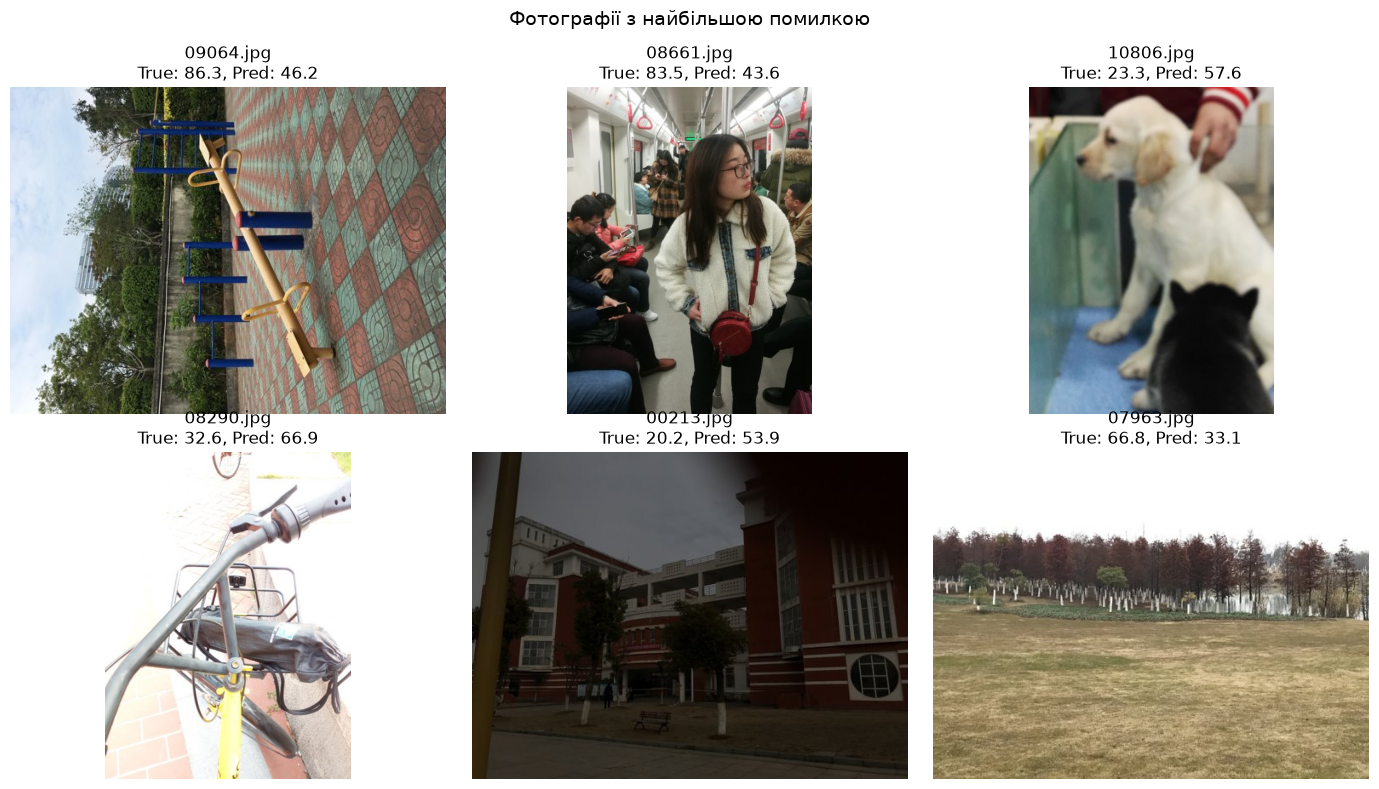

In [34]:
figure, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
)

axes = axes.flatten()

for axis, (_, row) in zip(
    axes,
    worst_predictions.iterrows(),
):
    image_path = (
        IMAGES_DIRECTORY
        / row["image_name"]
    )

    with Image.open(image_path) as image:
        axis.imshow(
            image.convert("RGB")
        )

    axis.set_title(
        f'{row["image_name"]}\n'
        f'True: '
        f'{row["true_overall_quality"]:.1f}, '
        f'Pred: '
        f'{row["predicted_overall_quality"]:.1f}'
    )

    axis.axis("off")

plt.suptitle(
    "Фотографії з найбільшою помилкою",
    fontsize=14,
)

plt.tight_layout()
plt.show()